# 08b — Final test-set evaluation with bootstrap confidence intervals (full MIMIC-IV)

**Question:** how good is the chosen model on patients it has never seen, and how wide is the
uncertainty on that number?

**Method:** fit XGBoost (chosen in 07b) and Logistic Regression (reference) on the 80% training
pool; evaluate **once** on the frozen 20% test set from `test_subject_ids.csv`; report AUROC,
AUPRC and Brier with 95% percentile-bootstrap CIs; check calibration.

Knowledge points: 8 (classification evaluation), 19 (calibration), 20 (bootstrap / CI).

In [1]:
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().parent
sys.path.insert(0, str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve

from src.config import RANDOM_STATE, TARGET_COLUMN, TABLES_DIR, FIGURES_DIR
from src.features.preprocessing import infer_feature_types, build_preprocessor
from src.models.logistic import build_logistic_model
from src.models.xgboost_model import build_xgboost, calculate_scale_pos_weight
from src.evaluation.resampling import bootstrap_metrics_table, format_estimate_with_ci

N_BOOTSTRAP = 1000

## 1. Load cohort and split using the frozen test IDs

Same file 07b wrote. If the ID file is missing, run 07b first — do **not** re-draw a split here.

In [2]:
df = pd.read_csv(PROJECT_DIR / "data/raw/full/modeling_cohort_full.csv")
test_subjects = pd.read_csv(PROJECT_DIR / "data/processed/full/test_subject_ids.csv")["subject_id"]

is_test = df["subject_id"].isin(test_subjects)
pool, test = df[~is_test].reset_index(drop=True), df[is_test].reset_index(drop=True)

assert not set(pool["subject_id"]) & set(test["subject_id"]), "patient leakage between pool and test"
print(f"pool {pool.shape}  positives {int(pool[TARGET_COLUMN].sum())}")
print(f"test {test.shape}  positives {int(test[TARGET_COLUMN].sum())}")

pool (68168, 73)  positives 7548
test (17074, 73)  positives 1927


## 2. Features (identical to 07b)

In [3]:
ID_AND_LEAKAGE = ["subject_id", "hadm_id", "stay_id", "intime", "outtime", "prediction_time", TARGET_COLUMN]
feature_columns = [c for c in pool.columns if c not in ID_AND_LEAKAGE]
numeric_features, categorical_features = infer_feature_types(pool, feature_columns)
preprocessor = build_preprocessor(numeric_features, categorical_features)

X_pool, y_pool = pool[feature_columns], pool[TARGET_COLUMN].to_numpy()
X_test, y_test = test[feature_columns], test[TARGET_COLUMN].to_numpy()

## 3. Fit on the full pool, predict on test — once

The preprocessor is fitted inside each pipeline on pool data only (no test statistics leak in).

In [4]:
models = {
    "xgboost": build_xgboost(preprocessor, scale_pos_weight=calculate_scale_pos_weight(y_pool)),
    "logistic": build_logistic_model(preprocessor),
}

test_probs = {}
for name, pipe in models.items():
    pipe.fit(X_pool, y_pool)
    test_probs[name] = pipe.predict_proba(X_test)[:, 1]
    print(name, "fitted")

xgboost fitted
logistic fitted


In [8]:
# Same XGBoost without class re-weighting — does the weight help discrimination, or only hurt calibration?
xgb_noweight = build_xgboost(preprocessor, scale_pos_weight=1.0)
xgb_noweight.fit(X_pool, y_pool)
test_probs["xgboost_noweight"] = xgb_noweight.predict_proba(X_test)[:, 1]
print("xgboost_noweight fitted")

xgboost_noweight fitted


## 4. Bootstrap 95% CIs on the test set

1000 resamples of the test rows with replacement; metric recomputed each time; CI = 2.5th–97.5th percentiles.

In [9]:
metric_fns = {
    "auroc": roc_auc_score,
    "auprc": average_precision_score,
    "brier": brier_score_loss,
}

tables = []
for name, p in test_probs.items():
    t = bootstrap_metrics_table(y_test, p, metric_fns, n_bootstrap=N_BOOTSTRAP)
    t.insert(0, "model", name)
    tables.append(t)

test_metrics = pd.concat(tables, ignore_index=True)
test_metrics["formatted"] = [
    format_estimate_with_ci(r.estimate, r.ci_low, r.ci_high) for r in test_metrics.itertuples()
]
test_metrics.to_csv(TABLES_DIR / "full_test_metrics_ci.csv", index=False)
test_metrics[["model", "metric", "formatted"]]

,model,metric,formatted
0,xgboost,auroc,0.890 (0.883–0.897)
1,xgboost,auprc,0.609 (0.589–0.630)
2,xgboost,brier,0.125 (0.123–0.128)
3,logistic,auroc,0.869 (0.860–0.876)
4,logistic,auprc,0.546 (0.524–0.569)
5,logistic,brier,0.143 (0.140–0.146)
6,xgboost_noweight,auroc,0.892 (0.884–0.899)
7,xgboost_noweight,auprc,0.617 (0.596–0.637)
8,xgboost_noweight,brier,0.066 (0.063–0.068)


## 5. Calibration curve

Reliability diagram with 10 quantile bins. Below the diagonal = over-predicting risk; above = under-predicting.
XGBoost with `scale_pos_weight` and LR with `class_weight='balanced'` both push probabilities up, so expect
some over-prediction — that's the motivation for the calibration step in notebook 08.

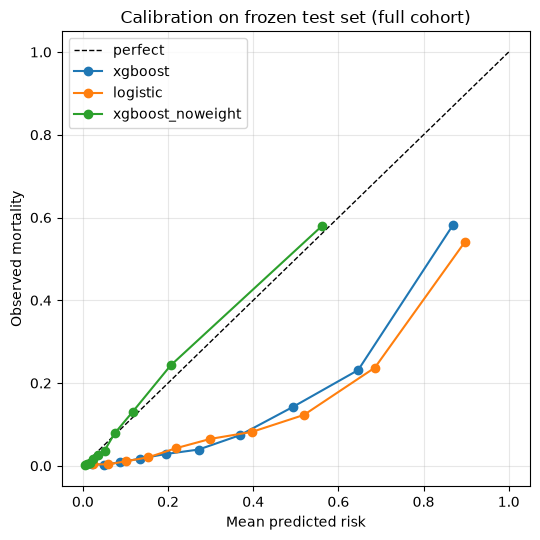

xgboost    mean predicted 0.314  observed 0.113
logistic   mean predicted 0.336  observed 0.113
xgboost_noweight mean predicted 0.110  observed 0.113


In [10]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
for name, p in test_probs.items():
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=name)
ax.set_xlabel("Mean predicted risk"); ax.set_ylabel("Observed mortality")
ax.set_title("Calibration on frozen test set (full cohort)")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "full_test_calibration_curve.png", dpi=150)
plt.show()

for name, p in test_probs.items():
    print(f"{name:10s} mean predicted {p.mean():.3f}  observed {y_test.mean():.3f}")

## 6. Write-up (fill in after the run)

- XGBoost test AUROC: __0.890 (0.883–0.897)_ ; AUPRC: _0.609 (0.589–0.630) __ ; Brier: _0.125 (0.123–0.128)__
- Does the test AUROC fall inside the 07b CV range (0.887–0.897)? __Yes_ (if yes, the CV estimate was honest)
- CI width for AUROC: __±0.007 with ~1,900 events _ — compare with the demo, where 2 positives made the CI essentially 0.3–1.0
- Calibration: over- or under-predicting, and by how much at the top decile? __over-predicting throughout. Top decile: predicted 0.87 vs observed 0.58. Brier 0.125 is worse than the constant-rate baseline (~0.098) even though discrimination is good — discrimination and calibration are separate properties._
- - Class weighting (scale_pos_weight ≈ 8) vs none: AUROC 0.890 → 0.892, AUPRC 0.609 → 0.617, Brier 0.125 → 0.066, and the calibration curve moves onto the diagonal. Weighting was a demo-era crutch for 11 events; with ~7,500 events it adds nothing to discrimination and badly hurts calibration. **Final model = unweighted XGBoost.**


"I report every test metric with a bootstrap CI because a point estimate hides how much
the number depends on which patients happened to land in the test set. With ~1,900 events the interval is
tight; on the demo data it was uninformative — which is exactly what the CI is for."
